In [1]:
!pip install -q giotto-tda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 8.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver el diagrama
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir los valores de la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Incluimos 'crime_lon', 'crime_lat' y la columna de distancias en los datos
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Diagrama de persistencia para el primer dataset

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    # Extraer las coordenadas de nacimiento y muerte
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Asegúrate de que ambos diagramas tengan el mismo tamaño
    max_len = max(len(births1), len(births2))
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular la distancia de Wasserstein para las coordenadas de nacimiento y muerte
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    # Combinar las distancias (puedes ajustar este paso si es necesario)
    return distance_births + distance_deaths

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

#HEAD CHECK
# Archivo CSV
file_path = 'Valencia_2015_Agresion.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias de Wasserstein entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = wasserstein_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias de Wasserstein entre diagramas de persistencia:")
print(dist_matrix)

Matriz de distancias de Wasserstein entre diagramas de persistencia:
[[0.         0.05158095 0.02464689 0.02419283 0.01365516 0.01955939
  0.0106254  0.01176047 0.0157046  0.03867791 0.01378253]
 [0.05158095 0.         0.02759079 0.02820276 0.0648205  0.07071385
  0.06169781 0.06254928 0.03745798 0.01724433 0.03936995]
 [0.02464689 0.02759079 0.         0.00646089 0.03742361 0.04313094
  0.03430149 0.03497566 0.01043598 0.0157009  0.01346363]
 [0.02419283 0.02820276 0.00646089 0.         0.03705913 0.04283211
  0.03390161 0.03469073 0.01177905 0.0161726  0.0124647 ]
 [0.01365516 0.0648205  0.03742361 0.03705913 0.         0.00738413
  0.00679476 0.00543652 0.0275745  0.05176716 0.02651061]
 [0.01955939 0.07071385 0.04313094 0.04283211 0.00738413 0.
  0.00991666 0.00954712 0.03329333 0.05766142 0.0321822 ]
 [0.0106254  0.06169781 0.03430149 0.03390161 0.00679476 0.00991666
  0.         0.00399694 0.0244139  0.04865669 0.02313504]
 [0.01176047 0.06254928 0.03497566 0.03469073 0.00543652 

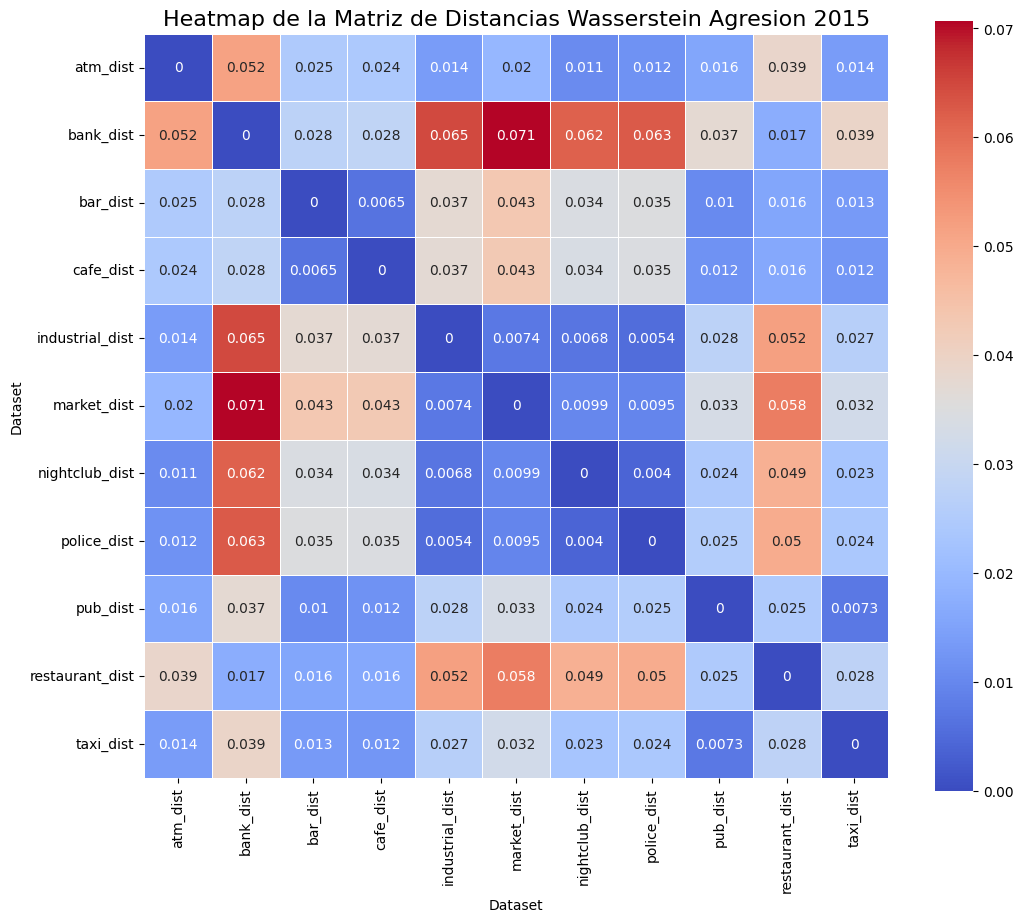

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Wasserstein
dist_matrix_wasserstein = np.array([
    [0.0, 0.05158095, 0.02464689, 0.02419283, 0.01365516, 0.01955939, 0.0106254, 0.01176047, 0.0157046, 0.03867791, 0.01378253],
    [0.05158095, 0.0, 0.02759079, 0.02820276, 0.0648205, 0.07071385, 0.06169781, 0.06254928, 0.03745798, 0.01724433, 0.03936995],
    [0.02464689, 0.02759079, 0.0, 0.00646089, 0.03742361, 0.04313094, 0.03430149, 0.03497566, 0.01043598, 0.0157009, 0.01346363],
    [0.02419283, 0.02820276, 0.00646089, 0.0, 0.03705913, 0.04283211, 0.03390161, 0.03469073, 0.01177905, 0.0161726, 0.0124647],
    [0.01365516, 0.0648205, 0.03742361, 0.03705913, 0.0, 0.00738413, 0.00679476, 0.00543652, 0.0275745, 0.05176716, 0.02651061],
    [0.01955939, 0.07071385, 0.04313094, 0.04283211, 0.00738413, 0.0, 0.00991666, 0.00954712, 0.03329333, 0.05766142, 0.0321822],
    [0.0106254, 0.06169781, 0.03430149, 0.03390161, 0.00679476, 0.00991666, 0.0, 0.00399694, 0.0244139, 0.04865669, 0.02313504],
    [0.01176047, 0.06254928, 0.03497566, 0.03469073, 0.00543652, 0.00954712, 0.00399694, 0.0, 0.02542577, 0.04952386, 0.0240192],
    [0.0157046, 0.03745798, 0.01043598, 0.01177905, 0.0275745, 0.03329333, 0.0244139, 0.02542577, 0.0, 0.02465288, 0.00734974],
    [0.03867791, 0.01724433, 0.0157009, 0.0161726, 0.05176716, 0.05766142, 0.04865669, 0.04952386, 0.02465288, 0.0, 0.02764581],
    [0.01378253, 0.03936995, 0.01346363, 0.0124647, 0.02651061, 0.0321822, 0.02313504, 0.0240192, 0.00734974, 0.02764581, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix_wasserstein, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Wasserstein Agresion 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()


In [4]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 30.3 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Usar 'crime_lon', 'crime_lat' y la columna de distancia
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte (dim 0 para H0, dim 1 para H1)
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Archivo CSV
file_path = 'Valencia_2015_Agresion.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias Bottleneck entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = bottleneck_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias Bottleneck entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias Bottleneck entre diagramas de persistencia:
[[0.         2.11770058 0.82446325 1.18064439 0.39026171 0.50898719
  0.22809404 0.83112109 0.35424817 2.00853944 0.44197381]
 [2.11770058 0.         2.03337979 1.11404586 2.11770058 2.11770058
  2.11770058 2.04776859 1.94044209 0.89481556 1.85271645]
 [0.82446325 2.03337979 0.         0.91933393 0.86900353 1.01509547
  0.75686169 0.71000856 0.78323698 1.81505752 0.44874704]
 [1.18064439 1.11404586 0.91933393 0.         1.26155114 1.32556713
  1.156425   0.93372273 0.82639623 1.12763655 0.73867059]
 [0.39026171 2.11770058 0.86900353 1.26155114 0.         0.25535089
  0.23269141 0.87566137 0.4516924  2.00853944 0.52288055]
 [0.50898719 2.11770058 1.01509547 1.32556713 0.25535089 0.
  0.44630915 1.01842439 0.54759169 2.00853944 0.68462431]
 [0.22809404 2.11770058 0.75686169 1.156425   0.23269141 0.44630915
  0.         0.76351953 0.33002877 2.00853944 0.46582729]
 [0.83112109 2.04776859 0.71000856 0.93372273 0.87566137 1.01

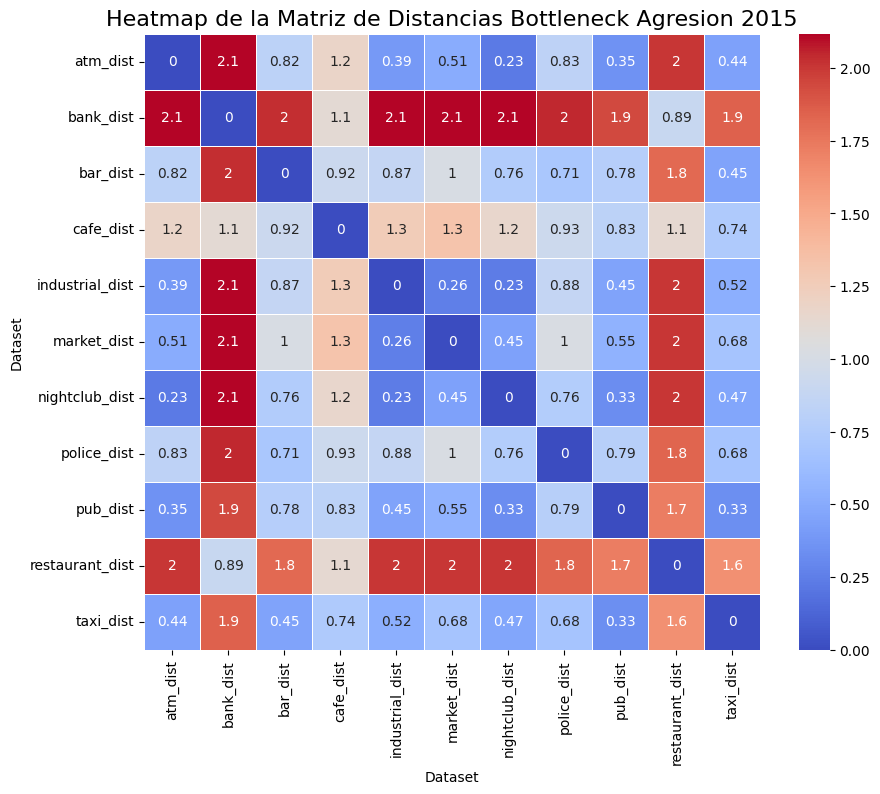

In [6]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Bottleneck
dist_matrix_bottleneck = np.array([
    [0.0, 2.11770058, 0.82446325, 1.18064439, 0.39026171, 0.50898719, 0.22809404, 0.83112109, 0.35424817, 2.00853944, 0.44197381],
    [2.11770058, 0.0, 2.03337979, 1.11404586, 2.11770058, 2.11770058, 2.11770058, 2.04776859, 1.94044209, 0.89481556, 1.85271645],
    [0.82446325, 2.03337979, 0.0, 0.91933393, 0.86900353, 1.01509547, 0.75686169, 0.71000856, 0.78323698, 1.81505752, 0.44874704],
    [1.18064439, 1.11404586, 0.91933393, 0.0, 1.26155114, 1.32556713, 1.156425, 0.93372273, 0.82639623, 1.12763655, 0.73867059],
    [0.39026171, 2.11770058, 0.86900353, 1.26155114, 0.0, 0.25535089, 0.23269141, 0.87566137, 0.4516924, 2.00853944, 0.52288055],
    [0.50898719, 2.11770058, 1.01509547, 1.32556713, 0.25535089, 0.0, 0.44630915, 1.01842439, 0.54759169, 2.00853944, 0.68462431],
    [0.22809404, 2.11770058, 0.75686169, 1.156425, 0.23269141, 0.44630915, 0.0, 0.76351953, 0.33002877, 2.00853944, 0.46582729],
    [0.83112109, 2.04776859, 0.71000856, 0.93372273, 0.87566137, 1.01842439, 0.76351953, 0.0, 0.78989482, 1.82944632, 0.68192172],
    [0.35424817, 1.94044209, 0.78323698, 0.82639623, 0.4516924, 0.54759169, 0.33002877, 0.78989482, 0.0, 1.72211981, 0.33448994],
    [2.00853944, 0.89481556, 1.81505752, 1.12763655, 2.00853944, 2.00853944, 2.00853944, 1.82944632, 1.72211981, 0.0, 1.63439417],
    [0.44197381, 1.85271645, 0.44874704, 0.73867059, 0.52288055, 0.68462431, 0.46582729, 0.68192172, 0.33448994, 1.63439417, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix_bottleneck, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Bottleneck Agresion 2015', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()
